# 02 — Entrenamiento del Modelo (YOLOv8n)

Este notebook realiza **transfer learning** de YOLOv8n sobre el dataset de fauna silvestre preparado en el notebook anterior.

**¿Qué hace?**
1. Verifica que haya GPU disponible
2. Monta Google Drive para acceder al dataset y guardar el modelo
3. Instala Ultralytics
4. Entrena YOLOv8n desde pesos preentrenados en COCO (`yolov8n.pt`)
5. Guarda el modelo entrenado y los resultados

**⚠️ IMPORTANTE:** Este notebook debe correrse en **Google Colab con GPU activada.**
- Menú: `Entorno de ejecución` → `Cambiar tipo de entorno de ejecución` → `T4 GPU`

**Tiempo estimado:** 1–3 horas (según la GPU asignada por Colab)

**Prerequisito:** Haber corrido `01_data_preparation.ipynb` y tener el dataset en Drive.

## 0. Verificar GPU

In [1]:
import subprocess
result = subprocess.run(["nvidia-smi"], capture_output=True, text=True)
if result.returncode == 0:
    print(result.stdout)
    print("✅ GPU disponible — listo para entrenar")
else:
    print("❌ NO hay GPU disponible.")
    print("   Ir a: Entorno de ejecución → Cambiar tipo de entorno → T4 GPU")
    raise RuntimeError("GPU requerida para este notebook")

Thu May 28 23:59:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Montar Google Drive

In [2]:
from google.colab import drive
drive.mount("/content/drive")

# ─── Ajustá esta ruta a donde subiste el proyecto en tu Drive ───────────────
PROJECT_ROOT = "/content/drive/MyDrive/Wildlife Camera Trap Detector/wildlife-detector"
DATA_YAML    = f"{PROJECT_ROOT}/data/data.yaml"
# ⚠️ OUTPUT_DIR apunta directo a Drive — los pesos se guardan ahí después de cada época
# Si Colab se resetea, el best.pt y last.pt ya están salvos en tu Drive
OUTPUT_DIR   = f"{PROJECT_ROOT}/outputs"

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"✅ Drive montado")
print(f"   data.yaml : {DATA_YAML}")
print(f"   outputs   : {OUTPUT_DIR}")

Mounted at /content/drive
✅ Drive montado
   data.yaml : /content/drive/MyDrive/Wildlife Camera Trap Detector/wildlife-detector/data/data.yaml
   outputs   : /content/drive/MyDrive/Wildlife Camera Trap Detector/wildlife-detector/outputs


## 2. Instalar Ultralytics

In [3]:
!pip install ultralytics -q

import ultralytics
ultralytics.checks()   # verifica GPU, CUDA y dependencias
print(f"\n✅ Ultralytics {ultralytics.__version__} instalado")

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.1/112.6 GB disk)

✅ Ultralytics 8.4.56 instalado


## 3. Configuración del entrenamiento

In [6]:
from ultralytics import YOLO

# ─── Hiperparámetros ──────────────────────────────────────────────────────────
MODEL_WEIGHTS = "yolov8n.pt"   # pesos preentrenados en COCO (se descargan automáticamente)
EPOCHS        = 30             # número de épocas de entrenamiento
IMG_SIZE      = 640            # resolución de entrada (estándar YOLO)
BATCH_SIZE    = 32             # ajustar según la VRAM disponible (T4=16GB → 16 ok)
PATIENCE      = 15             # early stopping: parar si no mejora en N épocas
WORKERS       = 2              # workers para DataLoader
PROJECT_NAME  = "wildlife_detector"  # nombre de la carpeta de resultados
RUN_NAME      = "yolov8n_gtm_v1"     # nombre de este experimento

# ─── Checkpoint / Reanudación ─────────────────────────────────────────────────
# Si Colab se resetea y querés continuar desde donde quedó:
#   1. Cambiá RESUME = True
#   2. MODEL_WEIGHTS se ignora y se usa last.pt automáticamente
RESUME = False
LAST_PT = f"{OUTPUT_DIR}/{PROJECT_NAME}/{RUN_NAME}/weights/last.pt"

print("Configuración de entrenamiento:")
print(f"  Modelo base : {MODEL_WEIGHTS}")
print(f"  Épocas      : {EPOCHS}")
print(f"  Imagen      : {IMG_SIZE}x{IMG_SIZE}")
print(f"  Batch size  : {BATCH_SIZE}")
print(f"  Early stop  : {PATIENCE} épocas")
print(f"  Dataset     : {DATA_YAML}")
print(f"  Reanudar    : {RESUME}")
if RESUME:
    import os
    if os.path.exists(LAST_PT):
        print(f"  Checkpoint  : {LAST_PT} ✅")
    else:
        print(f"  ⚠️  last.pt no encontrado en {LAST_PT} — se entrenará desde cero")
        RESUME = False

Configuración de entrenamiento:
  Modelo base : yolov8n.pt
  Épocas      : 30
  Imagen      : 640x640
  Batch size  : 32
  Early stop  : 15 épocas
  Dataset     : /content/drive/MyDrive/Wildlife Camera Trap Detector/wildlife-detector/data/data.yaml
  Reanudar    : False


## 4. Entrenar el modelo

Esta es la celda principal. Ultralytics se encarga de todo:
- Descarga los pesos `yolov8n.pt` si no los tiene
- Aplica data augmentation automático (flip, mosaic, HSV jitter, etc.)
- Guarda checkpoints cada época
- Aplica early stopping si `patience` épocas no mejoran el mAP50

Podés seguir el entrenamiento en la barra de progreso y en los logs.

In [7]:
# Cargar modelo — desde COCO (primera vez) o desde checkpoint (reanudación)
if RESUME and os.path.exists(LAST_PT):
    model = YOLO(LAST_PT)
    print(f"✅ Reanudando desde checkpoint: {LAST_PT}")
else:
    model = YOLO(MODEL_WEIGHTS)
    print(f"✅ Modelo base cargado: {MODEL_WEIGHTS}")
print(f"   Parámetros: {sum(p.numel() for p in model.model.parameters()):,}")

✅ Modelo base cargado: yolov8n.pt
   Parámetros: 3,157,200


In [8]:
# ─── ENTRENAMIENTO ────────────────────────────────────────────────────────────
results = model.train(
    data      = DATA_YAML,
    epochs    = EPOCHS,
    imgsz     = IMG_SIZE,
    batch     = BATCH_SIZE,
    patience  = PATIENCE,
    workers   = WORKERS,
    project   = OUTPUT_DIR,
    name      = RUN_NAME,
    exist_ok  = True,       # permite re-correr sin error si ya existe
    resume    = RESUME,     # True = reanudar desde last.pt, False = desde cero
    # Hiperparámetros de augmentation (valores por defecto de YOLOv8, buenos para empezar)
    hsv_h     = 0.015,      # jitter de hue
    hsv_s     = 0.7,        # jitter de saturación
    hsv_v     = 0.4,        # jitter de valor/brillo
    flipud    = 0.0,        # flip vertical (no aplica para cámaras trampa)
    fliplr    = 0.5,        # flip horizontal
    mosaic    = 1.0,        # mosaic augmentation (muy útil con pocos datos)
    degrees   = 5.0,        # rotación máxima
    translate = 0.1,        # traslación
    scale     = 0.5,        # escala
    verbose   = True,
)

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Wildlife Camera Trap Detector/wildlife-detector/data/data.yaml, degrees=5.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_gtm_v1, nbs=64, nms=False, opset=None, 

## 5. Resumen de resultados

In [9]:
import os
from pathlib import Path

# La ruta del mejor modelo guardado por Ultralytics
best_model_path = Path(OUTPUT_DIR) / RUN_NAME / "weights" / "best.pt"
last_model_path = Path(OUTPUT_DIR) / RUN_NAME / "weights" / "last.pt"

print("=" * 55)
print("ENTRENAMIENTO COMPLETADO")
print("=" * 55)
print(f"  Mejor modelo : {best_model_path}")
print(f"  Último modelo: {last_model_path}")
print(f"  Resultados   : {Path(OUTPUT_DIR) / RUN_NAME}")

# Métricas finales del mejor epoch
print("\nMétricas finales (mejor época):")
print(f"  mAP50     : {results.results_dict.get('metrics/mAP50(B)', 'N/A')}")
print(f"  mAP50-95  : {results.results_dict.get('metrics/mAP50-95(B)', 'N/A')}")
print(f"  Precision : {results.results_dict.get('metrics/precision(B)', 'N/A')}")
print(f"  Recall    : {results.results_dict.get('metrics/recall(B)', 'N/A')}")

print("\n✅ Siguiente paso → abrir 03_evaluation.ipynb")

ENTRENAMIENTO COMPLETADO
  Mejor modelo : /content/drive/MyDrive/Wildlife Camera Trap Detector/wildlife-detector/outputs/yolov8n_gtm_v1/weights/best.pt
  Último modelo: /content/drive/MyDrive/Wildlife Camera Trap Detector/wildlife-detector/outputs/yolov8n_gtm_v1/weights/last.pt
  Resultados   : /content/drive/MyDrive/Wildlife Camera Trap Detector/wildlife-detector/outputs/yolov8n_gtm_v1

Métricas finales (mejor época):
  mAP50     : 0.8633475149111643
  mAP50-95  : 0.6933281780461933
  Precision : 0.8965239182247423
  Recall    : 0.7914305966153184

✅ Siguiente paso → abrir 03_evaluation.ipynb


## 6. Curvas de entrenamiento

Ultralytics guarda automáticamente gráficas en la carpeta del experimento.

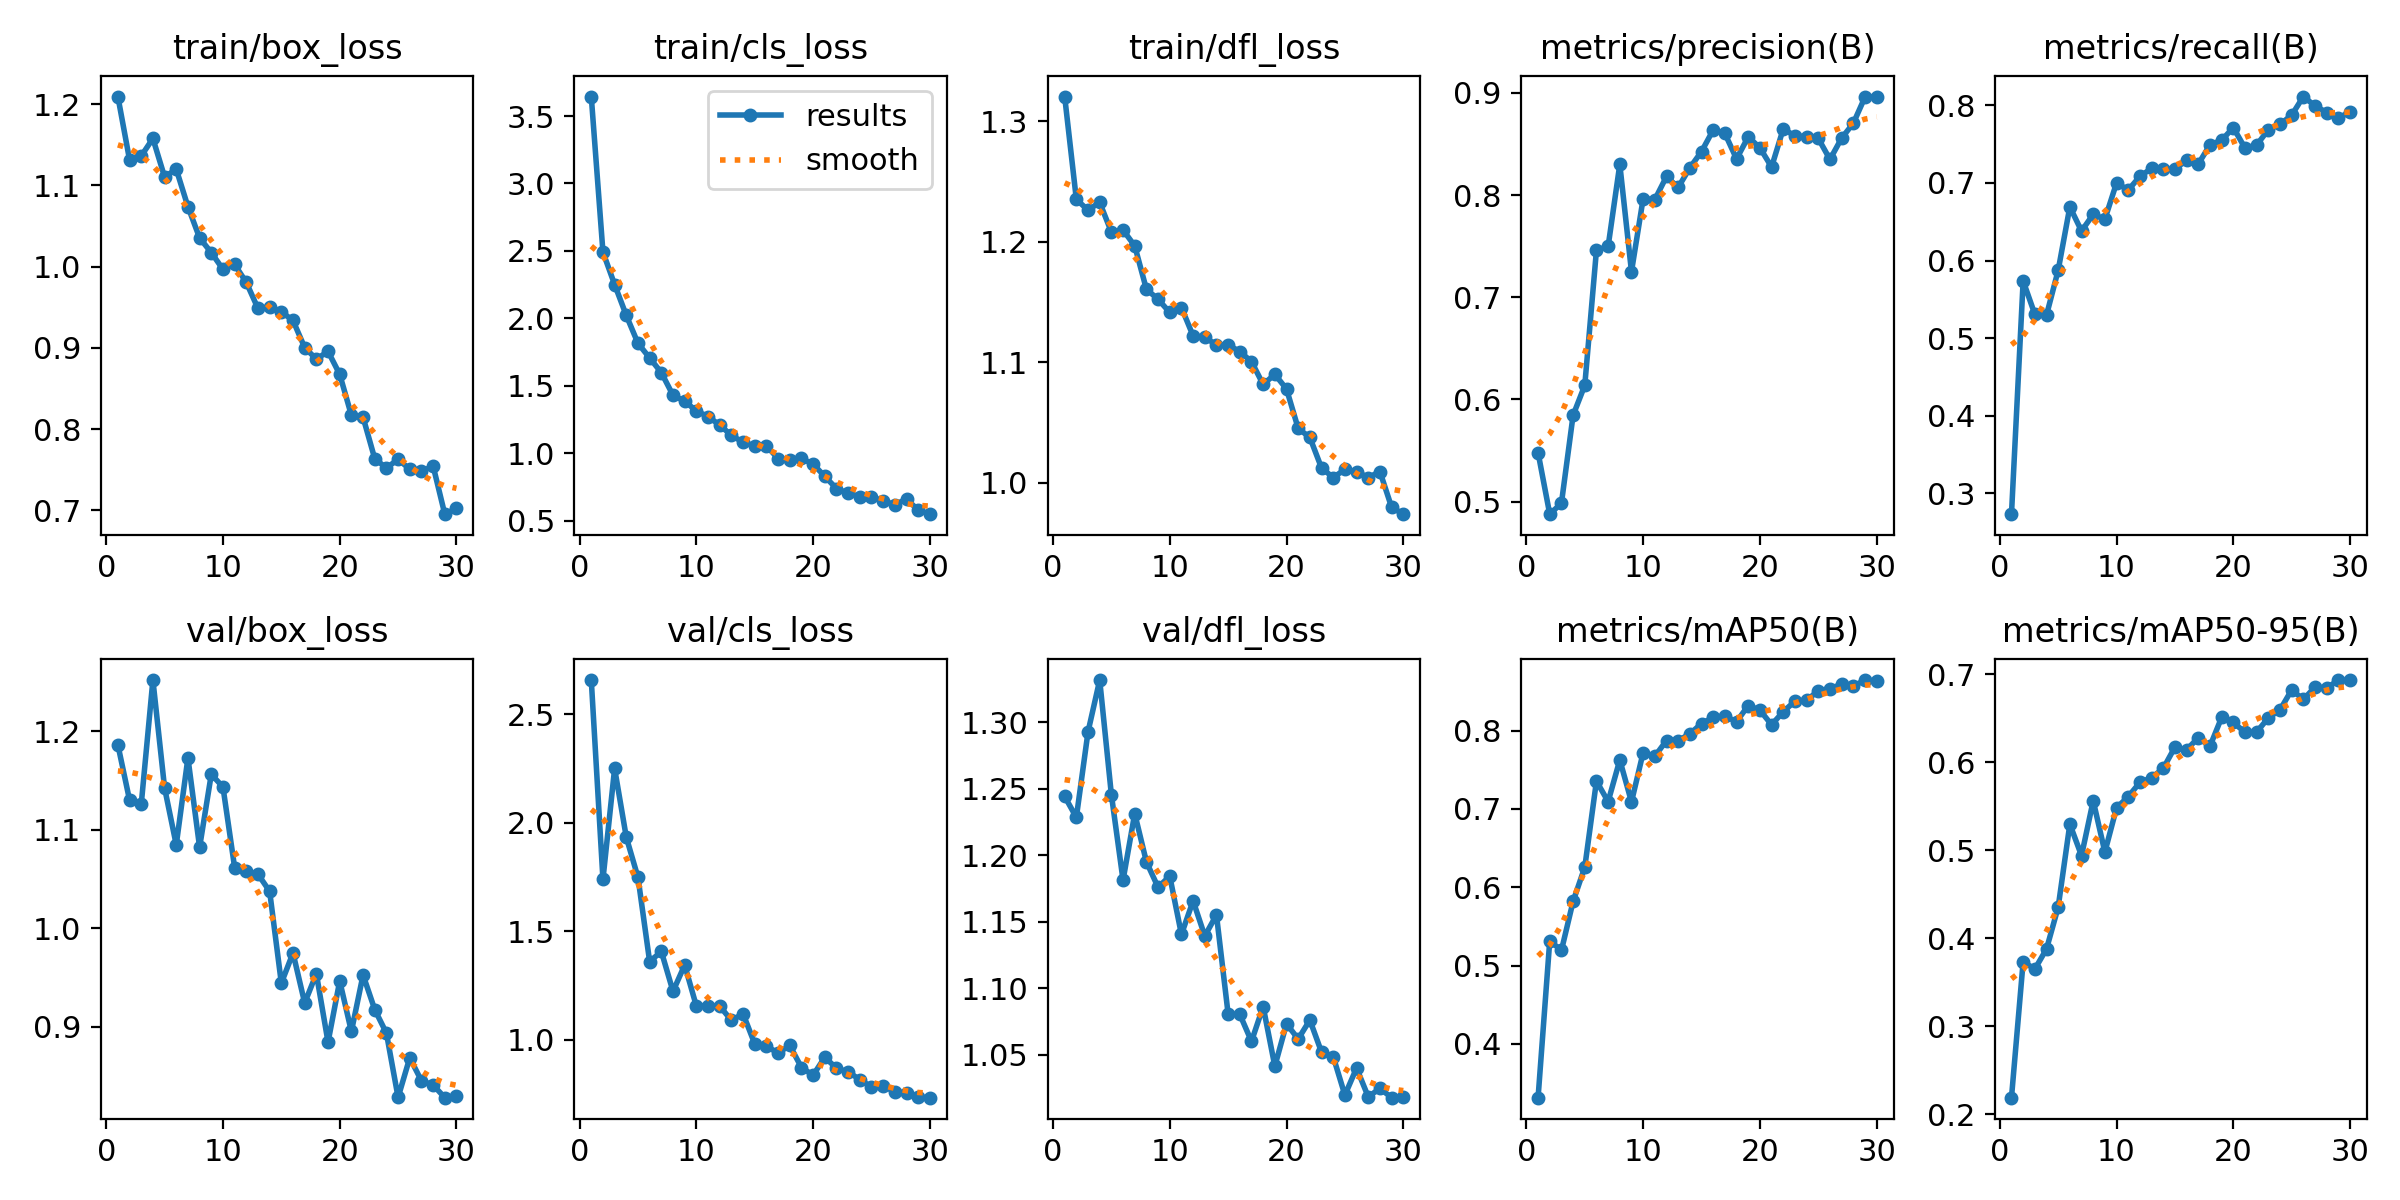

In [10]:
from IPython.display import Image, display
import glob

results_dir = Path(OUTPUT_DIR) / RUN_NAME

# Mostrar curvas de loss y métricas
results_png = results_dir / "results.png"
if results_png.exists():
    display(Image(str(results_png)))
else:
    print(f"Archivo de resultados no encontrado en {results_png}")
    print("Archivos disponibles:")
    for f in results_dir.glob("*.png"):
        print(f"  {f.name}")
        display(Image(str(f)))